In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from run_ranker import GetRecs

/Users/jessicakahn/Documents/repos/steering/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import random

In [10]:
base_path = '/Users/jessicakahn/Documents/repos/'
item_type = 'music'
model_name = 'phi'
# size_of_sample = 10
# layer_to_steer = 27
demo = 'gender'
device = "mps"
log_reg_type = 'reg'
with open(f'output_data/{item_type}/reverse_title_dict.json', 'r') as file_object:
    reverse_title_dict = json.load(file_object)
with open(f'output_data/{item_type}/processed_data_dict.json', 'r') as file:
    data_dict = json.load(file)
with open(f'output_data/{item_type}/gender_dict.json','r') as file:
    gender_dict = json.load(file)

In [11]:
get_recs = GetRecs(item_type, base_path, model_name)

Loading model:  microsoft/Phi-3-mini-128k-instruct


Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.47s/it]
Some parameters are on the meta device because they were offloaded to the disk.


In [12]:
# embedding_data_dict
n = len(data_dict)
# new_dict

In [13]:
items = list(data_dict.items())
    
np.random.seed(42)
size_of_sample=n
# Randomly sample the desired number of users
if size_of_sample > len(data_dict):
    size_of_sample = len(data_dict)
new_dict = dict(random.sample(items, size_of_sample))

In [14]:
# model_name

In [15]:
# This takes at least 45 mins(hours even)
embedding_data_dict = get_recs.get_prompts_hidden(new_dict,True)
file_path = f'output_data/{item_type}/embeddings/embed_{n}_{model_name}.pkl'


In [16]:
import pickle

In [17]:
with open(file_path, 'wb') as file_handle:
    pickle.dump(embedding_data_dict, file_handle)

In [ ]:
# Save this so don't have to rerun
# file_path




In [43]:
file_path = "output_data/music/embeddings/embed_642_llama3b.pkl"
with open(file_path, 'rb') as file:
    embedding_data_dict = pickle.load(file)

In [45]:
# embedding_data_dict[12]

In [49]:
### Run Regression ###
def get_regress_list( embedding_data_dict, log_reg_type='reg', demo_var='gender'):
        regress_dict = {}
        cv_results = []
        train_results = []
        if demo_var in( 'gender', 'age_binary'):
            scorer = 'roc_auc'
        else:
            scorer = make_scorer(
                roc_auc_score,
                multi_class='ovr', # or 'ovo'
                response_method="predict_proba",
                average='macro' # or 'weighted'
            )

        for key_layer, value in embedding_data_dict.items():
            if log_reg_type == 'reg':
                clf = LogisticRegression(max_iter=1000, solver='lbfgs')
            elif log_reg_type=='elastic':
                clf = LogisticRegression(
                    penalty='elasticnet',
                    solver='saga',
                    l1_ratio=0.5,  # 50% L1, 50% L2
                    C=0.1,
                    random_state=0
                )

            # Run regression for the 2 layers before layer_to_steer
            if (key_layer >= 0):
                X = [j['hidden'].detach().cpu() for j in value if demo_var in j['demo'] and j['demo'][demo_var]!='Unknown']
                # print('X:  ',X)
                X_tensor = torch.stack([
                    x.to(torch.float32)          # convert each element
                    .detach()
                    .cpu()
                    for x in X
                ])

                X_np = X_tensor.numpy()

                y = [j['demo'][demo_var] for j in value if demo_var in j['demo'] and j['demo'][demo_var]!='Unknown']
                print('LAYER: ',key_layer,' SHAPES X Y: ',X_np.shape, len(y), y)
                # Use these for multi-class
        
                skf = 5
                        
                clf = clf.fit(X_np, y)
                    
                scores = cross_val_score(clf, X_np, y, cv=skf, scoring=scorer)
                y_train_probs = clf.predict_proba(X_np)[:, 1]

                # 4. Calculate the ROC AUC score on the training set
                auc_train = roc_auc_score(y, y_train_probs)
                cv_results.append(np.array(scores).mean())
                train_results.append(auc_train)
                print('REGRESSION RESULTS: ', results)
                regress_dict[key_layer] = clf
            # else:
            #     regress_list.append(clf)

        return regress_dict, cv_results, train_results

regress_dict, cv_results, train_results = get_regress_list(embedding_data_dict)







# print('Regression results: ', results)
# with open(os.path.join(output_path, f'probes/results_{log_reg_type}_{date_string}_{model_name}.pkl'),'wb') as f:
#         pickle.dump(results,f)
# # i = 0



LAYER:  0  SHAPES X Y:  (642, 3072) 642 ['male', 'female', 'male', 'female', 'female', 'male', 'female', 'male', 'male', 'female', 'female', 'female', 'female', 'male', 'female', 'male', 'male', 'male', 'male', 'male', 'female', 'male', 'female', 'female', 'male', 'male', 'male', 'female', 'male', 'male', 'female', 'female', 'male', 'female', 'male', 'male', 'female', 'male', 'male', 'female', 'female', 'male', 'male', 'male', 'female', 'male', 'male', 'male', 'female', 'female', 'female', 'male', 'female', 'male', 'male', 'female', 'male', 'male', 'male', 'female', 'male', 'female', 'male', 'male', 'male', 'male', 'male', 'male', 'female', 'male', 'male', 'male', 'male', 'female', 'male', 'male', 'male', 'male', 'male', 'male', 'female', 'female', 'female', 'female', 'female', 'female', 'male', 'female', 'male', 'male', 'male', 'male', 'male', 'male', 'female', 'male', 'male', 'male', 'female', 'male', 'female', 'female', 'male', 'male', 'female', 'female', 'male', 'male', 'male', 'fe

In [50]:
# regress_dict
train_results

[0.8031537269073926,
 0.7524314503786644,
 0.7717744403961413,
 0.8293097149402133,
 0.8581612804486706,
 0.8466285533734215,
 0.8465001925412483,
 0.8594053931297332,
 0.865122387116522,
 0.8621404662460381,
 0.8625354226527248,
 0.8647175567996683,
 0.8769217097662847,
 0.8787088875065414,
 0.8845739901458376,
 0.9143438292998409,
 0.9345557234120284,
 0.9541554350938516,
 0.9678011789448739,
 0.9776750891120392,
 0.9851990086594192,
 0.9916861676392468,
 0.9953197665807637,
 0.9977981180327222,
 0.9988743742409432,
 0.9997136566051522,
 0.9999802521796657,
 1.0,
 1.0]

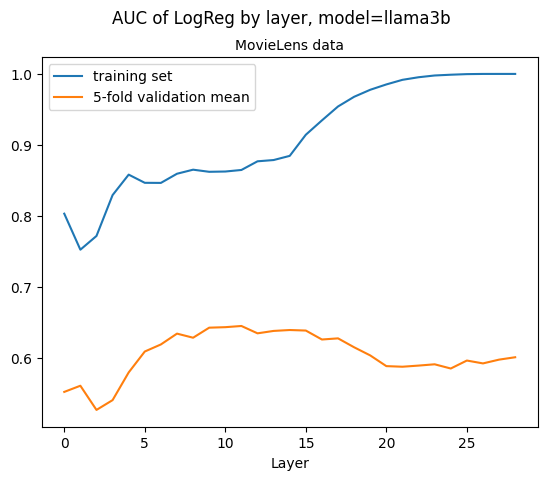

In [58]:
x = range(len(train_results)) 
plt.plot(x, train_results, label='training set')
plt.plot(x, cv_results, label='5-fold validation mean')
plt.suptitle(f'AUC of LogReg by layer, model={model_name}')
plt.title('MovieLens data', fontsize=10)
plt.xlabel('Layer')
plt.legend()

In [9]:
# Save regression
for k, mod in regress_dict.items():
    with open(f'output_data/movie/probes/model{k}_{log_reg_type}_{model_name}_{size_of_sample}.pkl','wb') as f:
        pickle.dump(mod,f)

In [ ]:
# Load regressions 
regress_dict = {}
num_records = 747
for i in [25,26,27]:
    with open(os.path.join(f'output_data/movie/probes/model{i}_{log_reg_type}_{model_name}_{num_records}.pkl'),'rb') as f:
        regress_dict[i] = pickle.load(f)

In [10]:
W_probe_l = torch.tensor(regress_dict[layer_to_steer].coef_, dtype=torch.float32, device=device)
W_probe_l_1 = torch.tensor(regress_dict[layer_to_steer-1].coef_, dtype=torch.float32, device=device)
pinv_W_Tl = torch.linalg.pinv(W_probe_l).T
pinv_W_Tl_1 = torch.linalg.pinv(W_probe_l_1).T

/var/folders/z4/ynvj_8y53mb4nn7qbl3fk1_40000gp/T/ipykernel_32827/4261788558.py:3: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  pinv_W_Tl = torch.linalg.pinv(W_probe_l).T


In [ ]:
W_probe_l.shape

In [13]:
model_id = "meta-llama/Llama-3.2-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16).to("mps")


`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:11<00:00,  5.97s/it]


In [ ]:
import torch

@torch.no_grad()
def hot_patch_steering(model, layer_idx, alpha, W_probe, pinv_W):
    # 1. Get the model's current dtype (likely float16 or bfloat16)
    target_dtype = model.dtype
    device = model.device

    # 2. Force the tensors into 1D vectors and ensure they match the model's type
    v1 = W_probe.reshape(-1).to(device=device, dtype=target_dtype)
    v2 = pinv_W.reshape(-1).to(device=device, dtype=target_dtype)
    
    # 3. Create the projection matrix using an OUTER PRODUCT
    proj = torch.outer(v1, v2) 
    
    # 4. Create Identity and calculate Steering Matrix M
    # Crucial: Specify dtype=target_dtype here
    dim = proj.shape[0]
    I = torch.eye(dim, device=device, dtype=target_dtype)
    M = I - (alpha * proj)

    # 5. Access the Llama weights
    layer = model.model.layers[layer_idx]
    
    # 6. Apply to weights (Now both M and .weight are the same dtype)
    layer.self_attn.o_proj.weight.copy_(torch.matmul(M, layer.self_attn.o_proj.weight))
    layer.mlp.down_proj.weight.copy_(torch.matmul(M, layer.mlp.down_proj.weight))

    # print(f"✅ Layer {layer_idx} patched. Dtype: {target_dtype} | Shape: {proj.shape}")



def get_ranking_score(model, tokenizer, query, document):
    full_text = f"Query: {query} Document: {document} Relevant: Yes"
    inputs = tokenizer(full_text, return_tensors="pt").to("cuda")
    
    with torch.inference_mode():
        # This runs your 'hot-patched' steered weights at full GPU speed
        outputs = model(**inputs)
        logits = outputs.logits # [1, seq_len, vocab_size]
        
    # Get the log-prob of the very last token (the "Yes" or relevance indicator)
    log_probs = torch.log_softmax(logits[:, -2, :], dim=-1) # Look at token before EOS
    target_id = tokenizer.convert_tokens_to_ids("Yes")
    return log_probs[0, target_id].item()

In [ ]:
def local_rank(model, tokenizer, history, candidates):
    scores = []

    history_ids = tokenizer(history, return_tensors="pt").to("mps")
    history_len = history_ids["input_ids"].shape[1]

    for movie in candidates:
        text = f"{history} Recommended: {movie}"
        inputs = tokenizer(text, return_tensors="pt").to("mps")

        with torch.inference_mode():
            outputs = model(**inputs)

        logits = outputs.logits
        log_probs = torch.log_softmax(logits, dim=-1)

        input_ids = inputs["input_ids"]

        # Only compute log prob of candidate tokens
        candidate_log_probs = []

        for i in range(history_len, input_ids.shape[1] - 1):
            token_id = input_ids[0, i+1]
            token_log_prob = log_probs[0, i, token_id]
            candidate_log_probs.append(token_log_prob)

        score = torch.sum(candidate_log_probs)
        scores.append((movie, score))

    return sorted(scores, key=lambda x: x[1], reverse=True)

In [ ]:
# import torch
import torch.nn.functional as F

def verify_steering(model, tokenizer, prompt, layer_idx, alpha, W_probe, pinv_W):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    # 1. Get Baseline (Unsteered) Logits
    with torch.inference_mode():
        original_outputs = model(**inputs)
        original_logits = original_outputs.logits[0, -1, :] # Last token logits
        original_probs = F.softmax(original_logits, dim=-1)

    # 2. Apply the Hot-Patch
    print(f"\n--- Applying Steering to Layer {layer_idx} ---")
    hot_patch_steering(model, layer_idx, alpha, W_probe, pinv_W)

    # 3. Get Steered Logits
    with torch.inference_mode():
        steered_outputs = model(**inputs)
        steered_logits = steered_outputs.logits[0, -1, :]
        steered_probs = F.softmax(steered_logits, dim=-1)

    # 4. Compare Results
    # Calculate the L2 distance between the probability distributions
    diff = torch.norm(original_probs - steered_probs).item()
    
    print(f"Steering Delta (L2 Distance): {diff:.6f}")
    
    if diff > 0:
        print("✅ SUCCESS: The model weights have been modified and predictions have shifted.")
        
        # Show top 3 tokens change
        top_orig = torch.topk(original_probs, 3)
        top_steer = torch.topk(steered_probs, 3)
        
        print("\nTop 3 Before -> Top 3 After:")
        for i in range(3):
            orig_tok = tokenizer.decode(top_orig.indices[i])
            steer_tok = tokenizer.decode(top_steer.indices[i])
            print(f"{i+1}. {orig_tok} ({top_orig.values[i]:.4f}) -> {steer_tok} ({top_steer.values[i]:.4f})")
    else:
        print("❌ FAILURE: No change detected. Check if alpha is too small or if weights weren't copied.")

# --- RUN VERIFICATION ---
test_prompt = "The best movie of all time is"
verify_steering(model, tokenizer, test_prompt, layer_to_steer, 10.0, W_probe_l, pinv_W_Tl)


In [ ]:
# 2. Apply your "Hot-Patch" logic here locally
# hot_patch_steering(model, layer_to_steer, 1, W_probe_l, pinv_W_Tl)
# hot_patch_steering(model, layer_to_steer-1, 1, W_probe_l_1, pinv_W_Tl_1)

In [ ]:
# len(data_dict.keys())
embedding_data_dict['1']

In [ ]:
user_id = '875'
d = data_dict[user_id]
history = ",".join(d['prompt_titles'])
candidates = d['pos_titles'] + d['neut_titles'] + d['neg_titles']
random.shuffle(candidates)
ranking = local_rank(history, candidates)

In [ ]:
steered_ids = []
for i in ranking:
    steered_ids += reverse_title_dict[i[0]]
steered_ids


In [ ]:
header = ['user_id', 'movie_id', 'rating', 'timestamp']
orig_rating_df = pd.read_csv('/Users/jessicakahn/Documents/repos/Glocal_K/1/ml-100k/u.data', sep='\t', names=header)
orig_rating_dict = (
    orig_rating_df.groupby("user_id")
      .apply(lambda g: dict(zip(g["movie_id"], g["rating"])))
      .to_dict()
)




/var/folders/z4/ynvj_8y53mb4nn7qbl3fk1_40000gp/T/ipykernel_39628/1785538435.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: dict(zip(g["movie_id"], g["rating"])))


In [ ]:
# Test with a single user
user_id = 875
actual = orig_rating_dict[user_id]

s = [actual.get(i) for i in steered_ids if actual.get(i) is not None]

print(f'Test: For a single user with user_id {user_id}: ')
print("NDCG@10: ",'steered: ', ndcg_at_k(s, 5) )

### test different layers

In [57]:
def rank_movies_steered(model, tokenizer, history, candidates):
    """
    Ranks movie candidates based on the model's likelihood scores.
    The model is assumed to be 'hot-patched' with steering weights.
    """
    model.eval()
    results = []
    
    # We use a consistent template for ranking
    base_prompt = f"User history: {history}. Recommended movie:"
    
    for movie in candidates:
        # Full text for this specific candidate
        full_text = f"{base_prompt} {movie}"
        # print('full text', full_text)
        # Tokenize and move to device (MPS for Mac, CUDA for GPU)
        inputs = tokenizer(full_text, return_tensors="pt").to(model.device)
        input_ids = inputs["input_ids"]
        
        with torch.inference_mode():
            outputs = model(**inputs)
            # Logits shape: [1, seq_len, vocab_size]
            logits = outputs.logits
            # print('LOGITS', logits)
            # print('LOGITS2', outputs.logits[0, :-1])
            # 1. Convert raw logits to log-probabilities
            log_probs = torch.log_softmax(logits, dim=-1)
            
            
            # 2. We only care about the log-probs of the "movie title" tokens
            # These are the tokens from the end of the prompt
            # Shift log_probs so they align with the input_ids
            # (The log_prob at index i predicts the token at index i+1)
            shift_log_probs = log_probs[..., :-1, :].contiguous()
            shift_input_ids = input_ids[..., 1:].contiguous()
            
            # 3. Gather the log-probs of the actual tokens that make up the movie title
            # We look at the last N tokens, where N is the length of the movie title
            movie_token_ids = tokenizer(f" {movie}", return_tensors="pt", add_special_tokens=False)["input_ids"]
            num_movie_tokens = movie_token_ids.shape[1]
            
            # Extract only the log-probs for the candidate movie title part
            target_log_probs = shift_log_probs[0, -num_movie_tokens:]
            target_ids = shift_input_ids[0, -num_movie_tokens:]
            
            # Gather the specific log-probs for the tokens in the title
            token_scores = target_log_probs.gather(1, target_ids.unsqueeze(1)).squeeze()
            
            # 4. Calculate the Mean Log-Probability for this movie
            mean_score = token_scores.mean().item()
            results.append((movie, mean_score))

    # Sort results: Higher (less negative) is better
    return sorted(results, key=lambda x: x[1], reverse=True)


In [ ]:
user_id = '875'
d = data_dict[user_id]
history = ",".join(d['prompt_titles'])
candidates = d['pos_titles'] + d['neut_titles'] + d['neg_titles']
random.shuffle(candidates)
local_rank(model, tokenizer,history, candidates)
rank_movies_steered(model, tokenizer,history, candidates)

In [ ]:
list(regress_dict.keys())

In [9]:
# Calculate W's at each layer
layers = list(regress_dict.keys())
W_dict = {i:None for i in layers}

for layer_to_steer in layers:
    W_probe_l = torch.tensor(regress_dict[layer_to_steer].coef_, dtype=torch.float32, device=device)
    pinv_W_Tl = torch.linalg.pinv(W_probe_l).T
    W_dict[layer_to_steer] = (W_probe_l.T,pinv_W_Tl)

/var/folders/z4/ynvj_8y53mb4nn7qbl3fk1_40000gp/T/ipykernel_39628/2278582376.py:7: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  pinv_W_Tl = torch.linalg.pinv(W_probe_l).T


In [ ]:
regress_dict.keys()

In [ ]:
# import torch

@torch.no_grad()
def test_layer_steering(model, tokenizer, layer_idx, alpha, W_dict, history, candidates):
    # --- 1. BACKUP (Save clean weights) ---
    layer = model.model.layers[layer_idx]
    orig_o = layer.self_attn.o_proj.weight.clone()
    orig_m = layer.mlp.down_proj.weight.clone()
    
    # --- 2. PATCH ---
    # Main layer
    hot_patch_steering(model, layer_idx, alpha, W_dict[layer_idx][0], W_dict[layer_idx][1])
    # Layer before
    hot_patch_steering(model, layer_idx-1, alpha, W_dict[layer_idx-1][0], W_dict[layer_idx-1][1])
    
    # --- 3. SCORE ---
    results = rank_movies_steered(model, tokenizer, history, candidates)
    
    # --- 4. RESET (Restore clean weights) ---
    layer.self_attn.o_proj.weight.copy_(orig_o)
    layer.mlp.down_proj.weight.copy_(orig_m)
    
    return results






In [58]:
# --- RUN THE SWEEP - BASELINE ---
# layers_to_test = [26, 27]
baseline_results = {}
counter = 0
for k,v in data_dict.items():
    # sweep_results[k] = {}
    history = ",".join(v['prompt_titles'])
    candidates = v['pos_titles'] + v['neut_titles'] + v['neg_titles']
    random.shuffle(candidates)
    results = rank_movies_steered(model, tokenizer,history, candidates)
    # print(results)
    counter += 1
    baseline_results[k] = results
    if counter % 10 ==0:
        print(counter)
    

10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
410
420
430
440
450
460
470
480
490
500
510
520
530
540
550
560
570
580
590
600
610
620
630
640
650
660
670
680
690
700
710
720
730
740


In [ ]:
# gender_dict
# sweep_results

In [ ]:
# Calculate NDCG for baseline results
baseline_ndcg_results = {}
for k, v in baseline_results.items():
    ranked_ids = [reverse_title_dict[i[0]] for i in v]
    flat_list = [item for sublist in ranked_ids for item in sublist]
    # print(flat_list)
    actual = orig_rating_dict[int(k)]
    s = [actual.get(i) for i in flat_list if actual.get(i) is not None]
    user_gender = gender_dict[k]
    baseline_ndcg_results[k]=dict(ndcg5 = ndcg_at_k(s, 5),
                         ndcg10=ndcg_at_k(s, 10), 
                         user_gender=user_gender)
    # print("NDCG@10: ",'steered: ', ndcg_at_k(s, 5) )

In [62]:
m5 = [v['ndcg5'] for k,v in baseline_ndcg_results.items() if v['user_gender']=='M']
f5 = [v['ndcg5'] for k,v in baseline_ndcg_results.items() if v['user_gender']=='F']
m10 = [v['ndcg10'] for k,v in baseline_ndcg_results.items() if v['user_gender']=='M']
f10 = [v['ndcg10'] for k,v in baseline_ndcg_results.items() if v['user_gender']=='F']

/var/folders/z4/ynvj_8y53mb4nn7qbl3fk1_40000gp/T/ipykernel_39628/122366801.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


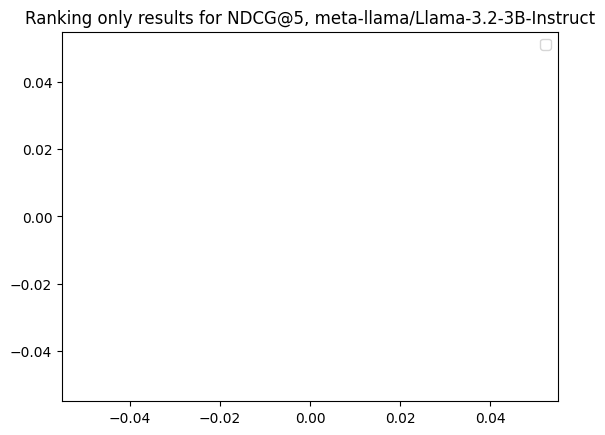

In [63]:
# Plot both densities
sns.kdeplot(m5, fill=True, label='M',clip=(0, 1))
sns.kdeplot(f5, fill=True, label='F',clip=(0, 1))
plt.title(f'Ranking only results for NDCG@5, {model_id}')
plt.legend()
plt.show()

In [ ]:
for k, v in sweep_results.items():
    print(k, v)

In [ ]:
baseline_results = rank_movies_steered(model, tokenizer, history, candidates)

In [ ]:
baseline_results

In [ ]:
# sweep_results[25]
# ==sweep_results[26]
steered_id_dict = {}
for k, v in sweep_results.items():
    steered_id_dict[k] = [reverse_title_dict[i[0]] for i in v]

    

In [ ]:
steered_id_dict

In [ ]:
# Main layer
hot_patch_steering(model, 26, 1.0, W_dict[26][0], W_dict[26][1])
# Layer before
hot_patch_steering(model, 27, 1.0, W_dict[27][0], W_dict[27][1])
layers_to_test = [26, 27]
steered_results = {}
counter = 0
for k,v in data_dict.items():
    # sweep_results[k] = {}
    history = ",".join(v['prompt_titles'])
    candidates = v['pos_titles'] + v['neut_titles'] + v['neg_titles']
    random.shuffle(candidates)
    results = rank_movies_steered(model, tokenizer,history, candidates)
    # print(results)
    counter += 1
    steered_results[k] = results
    if counter % 25 ==0:
        print(counter)

In [ ]:
steered_ndcg_results = {}
for k, v in sweep_results.items():
    ranked_ids = [reverse_title_dict[i[0]] for i in v]
    flat_list = [item for sublist in ranked_ids for item in sublist]
    # print(flat_list)
    actual = orig_rating_dict[int(k)]
    s = [actual.get(i) for i in flat_list if actual.get(i) is not None]
    user_gender = gender_dict[k]
    steered_ndcg_results[k]=dict(ndcg5 = ndcg_at_k(s, 5),
                         ndcg10=ndcg_at_k(s, 10), 
                         user_gender=user_gender)
m5 = [v['ndcg5'] for k,v in steered_ndcg_results.items() if v['user_gender']=='M']
f5 = [v['ndcg5'] for k,v in steered_ndcg_results.items() if v['user_gender']=='F']
m10 = [v['ndcg10'] for k,v in steered_ndcg_results.items() if v['user_gender']=='M']
f10 = [v['ndcg10'] for k,v in steered_ndcg_results.items() if v['user_gender']=='F']

In [ ]:
# steered_ndcg_results

In [ ]:
# Plot both densities
sns.kdeplot(m5, fill=True, label='M',clip=(0, 1))
sns.kdeplot(f5, fill=True, label='F',clip=(0, 1))
plt.title(f'Ranking only results for NDCG@5, {model_id}')
plt.legend()
plt.show()

In [ ]:
embedding_data_dict[25][0]['hidden'].shape

In [ ]:
W_dict[13][0].shape

In [ ]:
W_dict[13][0].shape

In [ ]:
user_id = '875'
d = data_dict[user_id]
history = ",".join(d['prompt_titles'])
candidates = d['pos_titles'] + d['neut_titles'] + d['neg_titles']
random.shuffle(candidates)
ranking = local_rank(model, tokenizer, history, candidates, W_dict)

# Back to hooks but still use logits instead

In [ ]:
for layer in model.model.layers:
    layer._forward_hooks.clear()

In [50]:
def local_rank(model, tokenizer, history, candidates, W_dict,alpha=20):
    scores = []
    layer_to_steer = 16

    # Clean up any previous hooks
    for layer in model.model.layers:
        layer._forward_hooks.clear()

    history_ids = tokenizer(history, return_tensors="pt").to("mps")
    history_len = history_ids["input_ids"].shape[1]

    def make_steering_hook(W_probe, alpha=1):
        # Preprocess: transpose & normalize once
        w = W_probe[0]
        if w.shape[0] == 1:
            w = w.T   # make [hidden_dim, 1]
        w = w / torch.norm(w)

        def steering_hook(module, input, output):
            hidden = output[0] if isinstance(output, tuple) else output

            # Move probe to same device/dtype as hidden
            w_curr = w.to(device=hidden.device, dtype=hidden.dtype)

            proj = (hidden @ w_curr) @ w_curr.T
            steered = hidden - alpha * proj

            if isinstance(output, tuple):
                return (steered,) + output[1:]
            return steered

        return steering_hook

    hook_prev = make_steering_hook(W_dict[layer_to_steer-1], alpha)
    hook_curr = make_steering_hook(W_dict[layer_to_steer], alpha)

    h_prev = model.model.layers[layer_to_steer-1].register_forward_hook(hook_prev)
    h_curr = model.model.layers[layer_to_steer].register_forward_hook(hook_curr)

    for movie in candidates:
        text = f"{history} Recommended: {movie}"
        inputs = tokenizer(text, return_tensors="pt").to("mps")

        with torch.inference_mode():
            outputs = model(**inputs)

        logits = outputs.logits
        log_probs = torch.log_softmax(logits, dim=-1)
        input_ids = inputs["input_ids"]

        candidate_log_probs = [
            log_probs[0, i, input_ids[0, i+1]] 
            for i in range(history_len, input_ids.shape[1] - 1)
        ]

        score = torch.sum(torch.stack(candidate_log_probs))
        scores.append((movie, score))

    # Remove hooks after loop
    h_prev.remove()
    h_curr.remove()

    return sorted(scores, key=lambda x: x[1], reverse=True)

In [51]:
steered_results = {}
counter = 0
for k,v in data_dict.items():
    # sweep_results[k] = {}
    history = ",".join(v['prompt_titles'])
    candidates = v['pos_titles'] + v['neut_titles'] + v['neg_titles']
    random.shuffle(candidates)
    results = local_rank(model, tokenizer,history, candidates, W_dict, alpha)
    # print(results)
    counter += 1
    steered_results[k] = results
    if counter % 25 ==0:
        print(counter)

25
50
75
100
125
150
175
200
225
250
275
300
325
350
375
400
425
450
475
500
525
550
575
600
625
650
675
700
725


In [ ]:
# Do we need a grid of layers and alphas to compare result
# b_data

{'1': {'user_gender': 'M',
  'ndcg_results': {'1': 1.0,
   '2': 0.8,
   '3': 0.8403030283801005,
   '4': 0.89672066785893,
   '5': 0.9051578253080036,
   '6': 0.8660659471044992,
   '7': 0.873997528288604,
   '8': 0.9141153429861969,
   '9': 0.9321190947827339,
   '10': 0.9331763222884272}},
 '2': {'user_gender': 'F',
  'ndcg_results': {'1': 0.2,
   '2': 0.6,
   '3': 0.5294697003348241,
   '4': 0.55983799642321,
   '5': 0.6502577112528652,
   '6': 0.6513794835719695,
   '7': 0.6720248076603168,
   '8': 0.701524348003245,
   '9': 0.7562124187498928,
   '10': 0.8067335696176874}},
 '3': {'user_gender': 'M',
  'ndcg_results': {'1': 0.8,
   '2': 0.8888888888888888,
   '3': 0.7489708611318783,
   '4': 0.7491230587436497,
   '5': 0.777469852385525,
   '6': 0.8167892091408172,
   '7': 0.8279924263574467,
   '8': 0.8012187923207428,
   '9': 0.8077828803925009,
   '10': 0.8417862760131971}},
 '5': {'user_gender': 'F',
  'ndcg_results': {'1': 0.6,
   '2': 0.6666666666666666,
   '3': 0.7396673768

In [52]:
# Calculate NDCG for baseline results
ndcg_results = {}
for k, v in steered_results.items():
    ranked_ids = [reverse_title_dict[i[0]] for i in v]
    flat_list = [item for sublist in ranked_ids for item in sublist]
    # print(flat_list)
    actual = orig_rating_dict[int(k)]
    s = [actual.get(i) for i in flat_list if actual.get(i) is not None]
    user_gender = gender_dict[k]
    ndcg_results[k]=dict(ndcg5 = ndcg_at_k(s, 5),
                         ndcg10=ndcg_at_k(s, 10), 
                         user_gender=user_gender)
    # print("NDCG@10: ",'steered: ', ndcg_at_k(s, 5) )

In [53]:
m5 = [v['ndcg5'] for k,v in ndcg_results.items() if v['user_gender']=='M']
f5 = [v['ndcg5'] for k,v in ndcg_results.items() if v['user_gender']=='F']
m10 = [v['ndcg10'] for k,v in ndcg_results.items() if v['user_gender']=='M']
f10 = [v['ndcg10'] for k,v in ndcg_results.items() if v['user_gender']=='F']

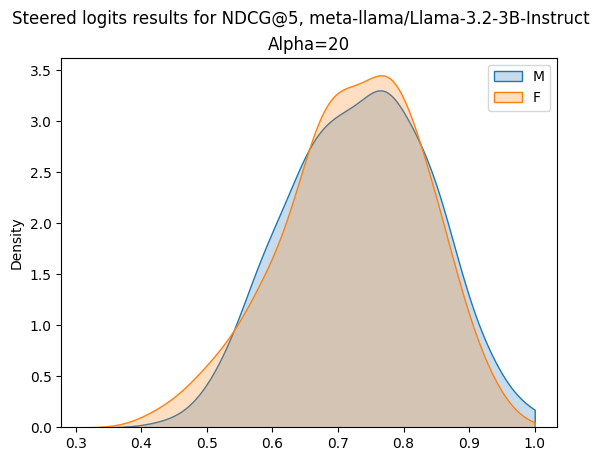

In [55]:
sns.kdeplot(m5, fill=True, label='M',clip=(0, 1))
sns.kdeplot(f5, fill=True, label='F',clip=(0, 1))
plt.suptitle(f'Steered logits results for NDCG@5, {model_id}')
plt.title('Alpha=20')
plt.legend()
plt.show()

## Load and plot results from run_logit_ranker script

In [16]:
file_str = f'output_data/movie/logit_outputs/steered_ndcg_{model_name}'
alpha_list = [1.0, 2.0, 5.0, 15.0, 20.0]
# layer_list = [14, 15, 16, 17, 18, 19, 20, 22, 24, 26]
layer_list = [28]
steered_results_list = []
for a in alpha_list:
    for l in layer_list:
        try:
            with open(file_str+f'_{l}_{a}.json', 'r', encoding='utf-8') as file:
            # Use json.load() to deserialize the file's content
                print('Loading file')
                s_data = json.load(file)
        except:
            # print('file not available')
            s_data = None
        inner_dict = dict(alpha=a, layer=l, data=s_data)
        steered_results_list.append(inner_dict)


In [17]:
# Load and plot results from run_logit_ranker
# baseline_path = 'output_data/movie/logit_outputs/baseline_ndcg_llama3b_10.json'
baseline_path = 'output_data/movie/logit_outputs/baseline_ndcg_phi_28_1.0.json'
# steered_path = 'output_data/movie/logit_outputs/steered_ndcg_llama3b_10.json'
# steered_a_l = 'output_data/movie/logit_outputs/steered_ndcg_llama3b_14_5.0.json'
with open(baseline_path, 'r', encoding='utf-8') as file:
        # Use json.load() to deserialize the file's content
    b_data = json.load(file)
# with open(steered_path, 'r', encoding='utf-8') as file:
#         # Use json.load() to deserialize the file's content
#     s_data = json.load(file)
# print(len(b_data), len(s_data))

In [189]:
rows = []

for entry in steered_results_list:
    alpha = entry["alpha"]
    layer = entry["layer"]
    
    # Skip if data is None
    if entry["data"] is None:
        continue
    
    for user_id, user_data in entry["data"].items():
        
        # Skip if individual user_data is None
        if user_data is None:
            continue
        
        row = {
            "alpha": alpha,
            "layer": layer,
            "user_id": user_id,
            "user_gender": user_data.get("user_gender"),
        }
        
        # Safely add ndcg results if they exist
        if user_data.get("ndcg_results") is not None:
            row.update(user_data["ndcg_results"])
        
        rows.append(row)

df = pd.DataFrame(rows)

# Optional: sort ndcg columns numerically
meta_cols = ["alpha", "layer", "user_id", "user_gender"]
ndcg_cols = sorted(
    [c for c in df.columns if c not in meta_cols],
    key=lambda x: int(x)
)

df = df[meta_cols + ndcg_cols]

In [134]:
# df.columns
# b_data['1']

In [190]:
df.alpha.unique()

array([ 1.,  2.,  5., 15., 20.])

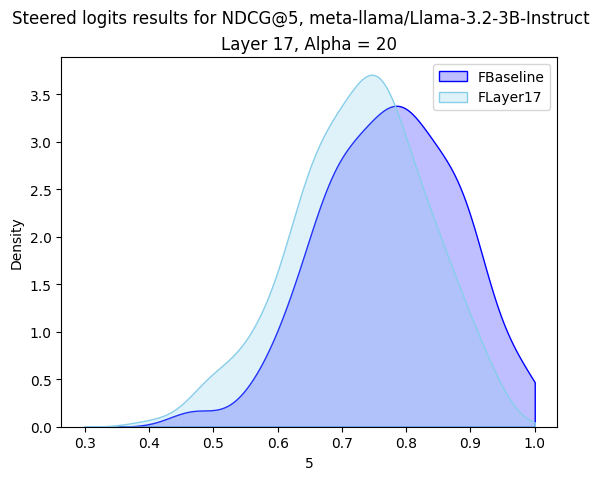

In [195]:
al = 20
ll = 17
# sns.kdeplot([v['ndcg_results']['5'] for k,v in b_data.items() if v['user_gender']=='M'], fill=True, label='MB',clip=(0, 1), color='darkorange')
sns.kdeplot([v['ndcg_results']['5'] for k,v in b_data.items() if v['user_gender']=='F'], fill=True, label='FBaseline',clip=(0, 1), color='blue')
# sns.kdeplot(df[(df.alpha==al) & (df.layer==ll) & (df.user_gender=='M')]['5'], fill=True, label='M14',clip=(0, 1))
sns.kdeplot(df[(df.alpha==al) & (df.layer==ll) & (df.user_gender=='F')]['5'], fill=True, label=f'FLayer{ll}',clip=(0, 1),color='skyblue')
# sns.kdeplot([v['ndcg_results']['5'] for k,v in b_data.items() if v['user_gender']=='M'], fill=True, label='MBaseline',clip=(0, 1), color='orangered')
# sns.kdeplot(df[(df.alpha==al) & (df.layer==ll) & (df.user_gender=='M')]['5'], fill=True, label='M14',clip=(0, 1))
# sns.kdeplot(df[(df.alpha==al) & (df.layer==ll) & (df.user_gender=='M')]['5'], fill=True, label=f'MLayer{ll}',clip=(0, 1),color='salmon')
plt.suptitle(f'Steered logits results for NDCG@5, {model_id}')
plt.title(f'Layer {ll}, Alpha = {al}')
plt.legend()
plt.show()

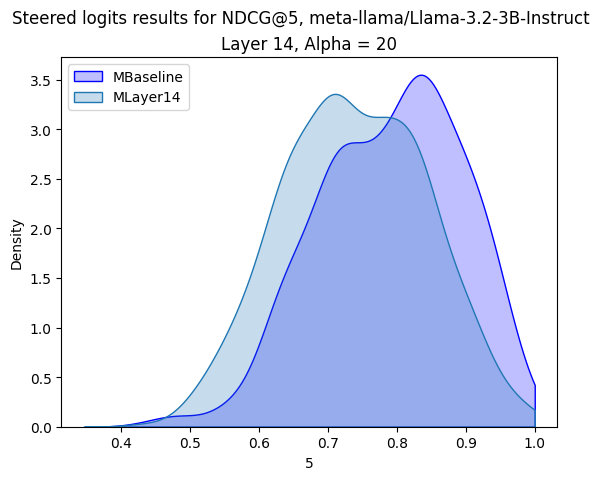

In [196]:
al = 20
ll = 14
# sns.kdeplot([v['ndcg_results']['5'] for k,v in b_data.items() if v['user_gender']=='M'], fill=True, label='MB',clip=(0, 1), color='darkorange')
sns.kdeplot([v['ndcg_results']['5'] for k,v in b_data.items() if v['user_gender']=='M'], fill=True, label='MBaseline',clip=(0, 1), color='blue')
# sns.kdeplot(df[(df.alpha==al) & (df.layer==ll) & (df.user_gender=='M')]['5'], fill=True, label='M14',clip=(0, 1))
sns.kdeplot(df[(df.alpha==al) & (df.layer==ll) & (df.user_gender=='M')]['5'], fill=True, label=f'MLayer{ll}',clip=(0, 1))

plt.suptitle(f'Steered logits results for NDCG@5, {model_id}')
plt.title(f'Layer {ll}, Alpha = {al}')
plt.legend()
plt.show()

In [198]:
tt = df.groupby(['alpha','layer','user_gender'])[['1','2','3','4','5','6','7','8','9','10']].mean().reset_index()
# tt.to_csv()


In [199]:
df_long = pd.melt(tt,
                  id_vars=['alpha','layer','user_gender'],
                  var_name='k',
                  value_name='ndcg')

In [212]:
# Pivot gender back
df_wide = df_long.pivot(
    index=['alpha','layer','k'], 
    columns='user_gender', 
    values='ndcg')
df_wide.columns.name = None
df_wide = df_wide.reset_index()

In [223]:
df_wide['k'] = df_wide['k'].astype(int)


In [236]:
# b_data

In [18]:

rows = []

for user_id, user_data in b_data.items():
    gender = user_data["user_gender"]
    
    for k, ndcg in user_data["ndcg_results"].items():
        rows.append({
            "user_id": user_id,
            "user_gender": gender,
            "k": int(k),
            "ndcg": ndcg
        })

bdf = pd.DataFrame(rows)

In [20]:
# bl_df_wide.head()

In [21]:
bl_df = bdf.groupby(['user_gender','k'])['ndcg'].mean().reset_index()

In [22]:
bl_df_wide = bl_df.pivot(
    index='k', 
    columns='user_gender', 
    values='ndcg').reset_index()

In [256]:
# bl_df_wide
subdf

,alpha,layer,k,F,M
490,20.0,26,1,0.666748,0.661460
491,20.0,26,10,0.871282,0.865228
492,20.0,26,2,0.695685,0.675878
493,20.0,26,3,0.713923,0.690594
494,20.0,26,4,0.715175,0.701027
495,20.0,26,5,0.743451,0.731495
496,20.0,26,6,0.764565,0.757462
497,20.0,26,7,0.782328,0.775918
498,20.0,26,8,0.810443,0.802563
499,20.0,26,9,0.840624,0.833357


Text(0.5, 1.0, 'Baseline NDCG@k for phi')

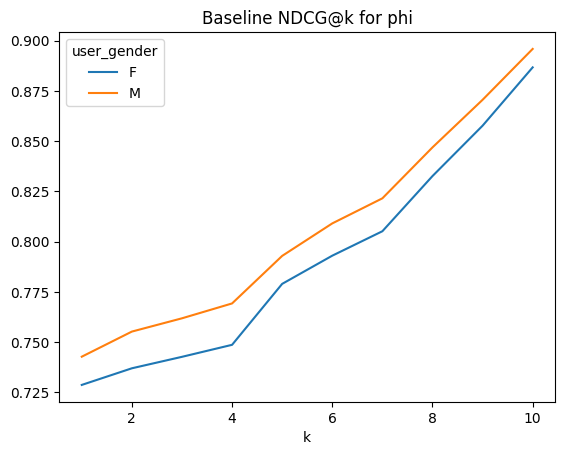

In [28]:
# Plot baseline only
bl_df_wide_plot = bl_df_wide.set_index('k')
bl_df_wide_plot.plot(kind='line')
plt.title(f"Baseline NDCG@k for {model_name}")

In [23]:
for a in alpha_list:
    for lay in layer_list:
        subdf = df_wide[(df_wide.alpha==a) & (df_wide.layer==lay)]
        subdf.columns = ['alpha','layer','k','Steered_F','Steered_M']
        ax = subdf.sort_values('k').plot(x='k', y=['Steered_F', 'Steered_M'])

        # 2. Plot the reference line from the second DataFrame onto the same 'ax'
        # 'ref_df' is your second dataframe
        bl_df_wide.sort_values('k').plot(x='k', y='F', ax=ax, 
                                    label='Baseline F', linestyle='--', color='steelblue')
        bl_df_wide.sort_values('k').plot(x='k', y='M', ax=ax, 
                                    label='Baseline M', linestyle='--', color='orange')                             

        plt.ylabel('NDCG')
        plt.suptitle('NDCG with Reference Line')
        plt.title(f'Alpha={a}, Layer={lay}')
        plt.show()

NameError: name 'df_wide' is not defined

In [ ]:
for a in alpha_list:
    for lay in layer_list:
        subdf = df_long[(df_long.alpha==a) & (df_long.layer==lay)].set_index('k')
        subdf.plot.line()


,alpha,layer,user_gender,k,ndcg
0,1.0,14,F,1,0.747087
1,1.0,14,M,1,0.768484
2,1.0,15,F,1,0.749029
3,1.0,15,M,1,0.766728
4,1.0,16,F,1,0.748058


AttributeError: Line2D.set() got an unexpected keyword argument 'labels'

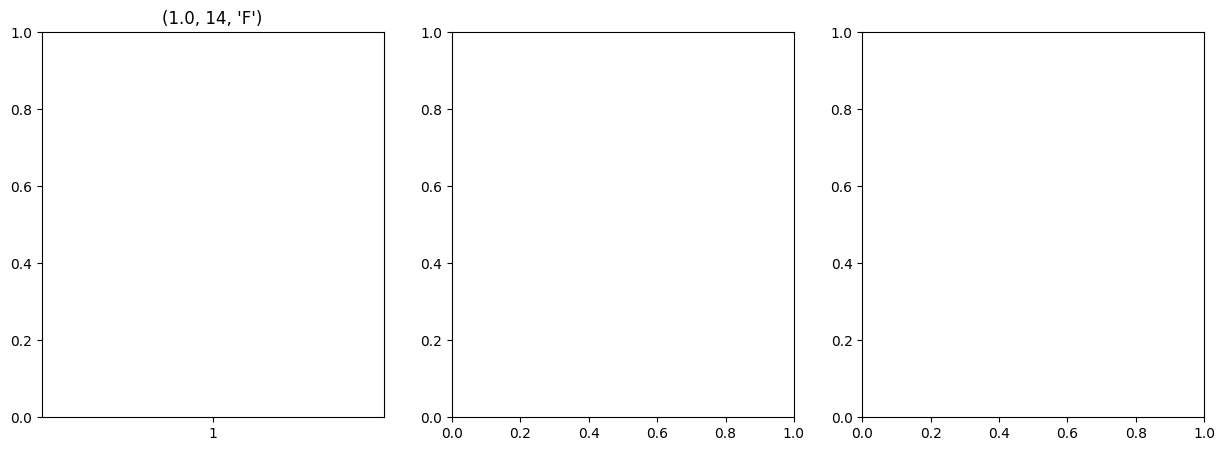

In [187]:
# tt.reset_index().T
# Plotting in subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

for i, (name, row) in enumerate(tt.iterrows()):
    ax = axes[i]
    ax.set_title(name)
    ax.plot(row, labels=row.index, autopct='%1.1f%%') # Example using a pie chart

plt.tight_layout()
plt.show()

In [83]:
m5b = [v['ndcg_results']['5'] for k,v in b_data.items() if v['user_gender']=='M']
f5b = [v['ndcg_results']['5'] for k,v in b_data.items() if v['user_gender']=='F']
m10b = [v['ndcg_results']['10'] for k,v in b_data.items() if v['user_gender']=='M']
f10b = [v['ndcg_results']['10'] for k,v in b_data.items() if v['user_gender']=='F']

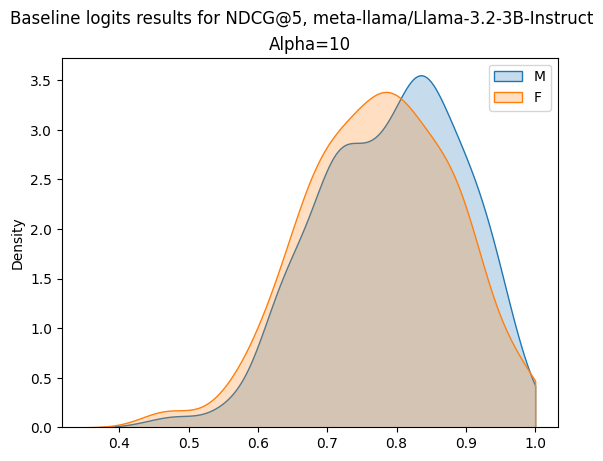

In [84]:
sns.kdeplot(m5b, fill=True, label='M',clip=(0, 1))
sns.kdeplot(f5b, fill=True, label='F',clip=(0, 1))
plt.suptitle(f'Baseline logits results for NDCG@5, {model_id}')
plt.title('Alpha=10')
plt.legend()
plt.show()

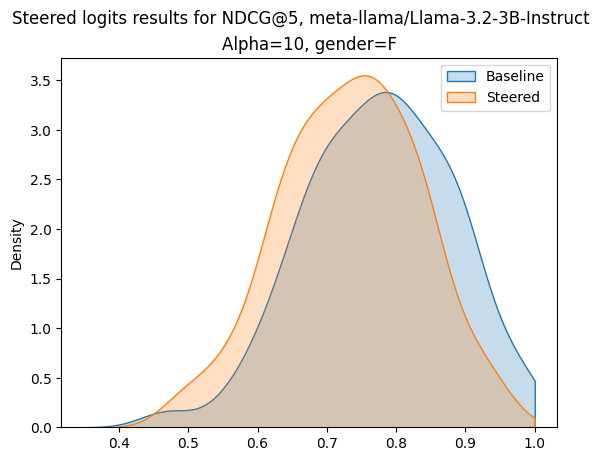

In [85]:
m5s = [v['ndcg_results']['5'] for k,v in s_data.items() if v['user_gender']=='M']
f5s = [v['ndcg_results']['5'] for k,v in s_data.items() if v['user_gender']=='F']
sns.kdeplot(f5b, fill=True, label='Baseline',clip=(0, 1))
sns.kdeplot(f5s, fill=True, label='Steered',clip=(0, 1))
plt.suptitle(f'Steered logits results for NDCG@5, {model_id}')
plt.title('Alpha=10, gender=F')
plt.legend()
plt.show()

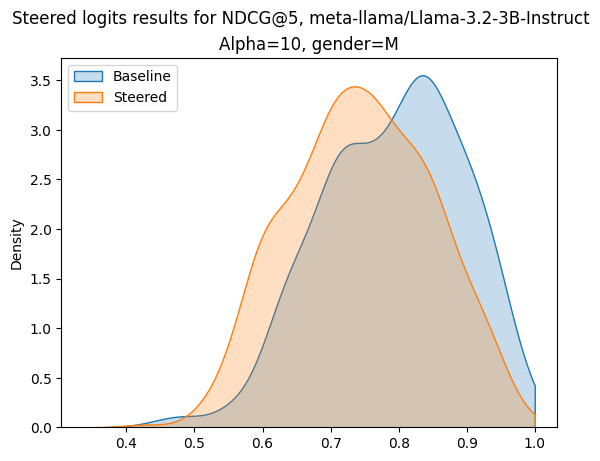

In [86]:
sns.kdeplot(m5b, fill=True, label='Baseline',clip=(0, 1))
sns.kdeplot(m5s, fill=True, label='Steered',clip=(0, 1))
plt.suptitle(f'Steered logits results for NDCG@5, {model_id}')
plt.title('Alpha=10, gender=M')
plt.legend()
plt.show()